# A copula variational family for probabilities

Mean-field guides treat latent probabilities as independent, and for
many posteriors that is exactly what is wrong with them. The standard
fix is a Gaussian copula: correlate the latents through a multivariate
normal, then push each coordinate through a marginal quantile function.
For Beta marginals that requires the Beta quantile, differentiable in
the uniform input *and* in the shape parameters, which is the piece the
jax ecosystem has been missing (jax#5350, jax#38610). chebax's
`betaincinv` provides it, so the whole family below trains end to end
with plain `jax.grad`.

    eps ~ N(0, I)  ->  z = correlate(eps; rho)  ->  u = Phi(z)
        ->  theta_i = betaincinv(a_i, b_i, u_i)

Every arrow is differentiable, so this is a fully reparameterized,
correlated distribution over probabilities.

In [1]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

jax.config.update("jax_enable_x64", True)

import numpyro
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS

import chebax

## A posterior that mean-field cannot represent

Series-system reliability: a device works only if both of its
components work, so a system test succeeds with probability
theta_1 * theta_2. We observe mostly system-level tests and only a
few expensive per-component tests:

- 48 successes in 60 system trials
- 7/8 for component 1, 6/8 for component 2

The system data pins down the *product*, so the posterior over
(theta_1, theta_2) is a negatively correlated ridge: if one component
is better, the other must be worse.

In [2]:
N_SYS, Y_SYS = 60, 48
N_C, Y1, Y2 = 8, 7, 6


def log_joint(t1, t2):
    lp = dist.Beta(2.0, 2.0).log_prob(t1) + dist.Beta(2.0, 2.0).log_prob(t2)
    lp += dist.Binomial(N_C, probs=t1).log_prob(Y1)
    lp += dist.Binomial(N_C, probs=t2).log_prob(Y2)
    lp += dist.Binomial(N_SYS, probs=t1 * t2).log_prob(Y_SYS)
    return lp


# NUTS reference posterior
def model():
    t1 = numpyro.sample("t1", dist.Beta(2.0, 2.0))
    t2 = numpyro.sample("t2", dist.Beta(2.0, 2.0))
    numpyro.sample("y1", dist.Binomial(N_C, probs=t1), obs=Y1)
    numpyro.sample("y2", dist.Binomial(N_C, probs=t2), obs=Y2)
    numpyro.sample("ys", dist.Binomial(N_SYS, probs=t1 * t2), obs=Y_SYS)


mcmc = MCMC(NUTS(model), num_warmup=1000, num_samples=2000, progress_bar=False)
mcmc.run(jax.random.PRNGKey(0))
ref = mcmc.get_samples()
ref_corr = float(np.corrcoef(ref["t1"], ref["t2"])[0, 1])
print(f"NUTS posterior correlation of (t1, t2): {ref_corr:+.3f}")

NUTS posterior correlation of (t1, t2): -0.426


## The guide

Marginals are Beta(a_i, b_i); the copula is a bivariate normal with
correlation rho. The log density follows from the change of variables

$$\log q(\theta) = \log N_2(z; 0, C) \;+\; \sum_i
  \big[\log f_{\mathrm{Beta}}(\theta_i; a_i, b_i) - \log\varphi(z_i)\big]$$

The mean-field Beta guide is the same family with rho frozen at zero,
so the comparison below is exactly "what does the copula buy".

In [3]:
from jax.scipy.stats import beta as beta_stats
from jax.scipy.stats import norm as norm_stats


def unpack(phi):
    # marginal shapes kept inside the betaincinv table domain [0.1, 10]
    ab = 0.2 + 9.6 * jax.nn.sigmoid(phi[:4])
    rho = jnp.tanh(phi[4])
    return ab[0], ab[1], ab[2], ab[3], rho


def guide_sample(phi, eps, learn_rho=True):
    """eps: (M, 2) standard normal. Returns theta (M, 2) and log q per row."""
    a1, b1, a2, b2, rho = unpack(phi)
    rho = jnp.where(learn_rho, rho, 0.0)
    z1 = eps[:, 0]
    z2 = rho * eps[:, 0] + jnp.sqrt(1.0 - rho ** 2) * eps[:, 1]
    log_mvn = (norm_stats.logpdf(eps[:, 0]) + norm_stats.logpdf(eps[:, 1])
               - 0.5 * jnp.log1p(-rho ** 2))
    u1 = jnp.clip(norm_stats.cdf(z1), 1e-14, 1 - 1e-14)
    u2 = jnp.clip(norm_stats.cdf(z2), 1e-14, 1 - 1e-14)
    t1 = chebax.betaincinv(a1, b1, u1)
    t2 = chebax.betaincinv(a2, b2, u2)
    log_q = (log_mvn
             + beta_stats.logpdf(t1, a1, b1) - norm_stats.logpdf(z1)
             + beta_stats.logpdf(t2, a2, b2) - norm_stats.logpdf(z2))
    return jnp.stack([t1, t2], axis=1), log_q


def neg_elbo(phi, eps, learn_rho):
    theta, log_q = guide_sample(phi, eps, learn_rho)
    return -(jax.vmap(log_joint)(theta[:, 0], theta[:, 1]) - log_q).mean()

## Training both guides

In [4]:
def train(learn_rho, steps=1500, m=256, lr=0.02, seed=10):
    grad_fn = jax.jit(jax.value_and_grad(neg_elbo), static_argnums=2)
    phi = jnp.zeros(5)
    mom = vel = jnp.zeros_like(phi)
    b1, b2, e = 0.9, 0.999, 1e-8
    key = jax.random.PRNGKey(seed)
    for i in range(steps):
        key, k = jax.random.split(key)
        eps = jax.random.normal(k, (m, 2))
        val, g = grad_fn(phi, eps, learn_rho)
        mom = b1 * mom + (1 - b1) * g
        vel = b2 * vel + (1 - b2) * g * g
        phi = phi - lr * (mom / (1 - b1 ** (i + 1))) / (
            jnp.sqrt(vel / (1 - b2 ** (i + 1))) + e)
    # final large-sample ELBO estimate
    eps = jax.random.normal(jax.random.PRNGKey(99), (40000, 2))
    return phi, -float(neg_elbo(phi, eps, learn_rho))


phi_mf, elbo_mf = train(learn_rho=False)
phi_cop, elbo_cop = train(learn_rho=True)

eps = jax.random.normal(jax.random.PRNGKey(7), (4000, 2))
th_mf, _ = guide_sample(phi_mf, eps, learn_rho=False)
th_cop, _ = guide_sample(phi_cop, eps, learn_rho=True)
cop_corr = float(np.corrcoef(th_cop[:, 0], th_cop[:, 1])[0, 1])

print(f"ELBO  mean-field: {elbo_mf:.4f}")
print(f"ELBO  copula:     {elbo_cop:.4f}   (higher is better)")
print(f"correlation of (t1, t2):  copula guide {cop_corr:+.3f}, "
      f"NUTS {ref_corr:+.3f}, mean-field 0 by construction")

# the decision-relevant quantity: uncertainty about the system reliability
ps = {"NUTS": np.asarray(ref["t1"] * ref["t2"]),
      "copula": np.asarray(th_cop[:, 0] * th_cop[:, 1]),
      "mean-field": np.asarray(th_mf[:, 0] * th_mf[:, 1])}
for k, v in ps.items():
    print(f"system reliability t1*t2 under {k:10s}: "
          f"mean {v.mean():.3f}, sd {v.std():.3f}")

ELBO  mean-field: -11.5394
ELBO  copula:     -10.7932   (higher is better)
correlation of (t1, t2):  copula guide -0.654, NUTS -0.426, mean-field 0 by construction
system reliability t1*t2 under NUTS      : mean 0.743, sd 0.051
system reliability t1*t2 under copula    : mean 0.716, sd 0.083
system reliability t1*t2 under mean-field: mean 0.714, sd 0.125


## What the copula buys

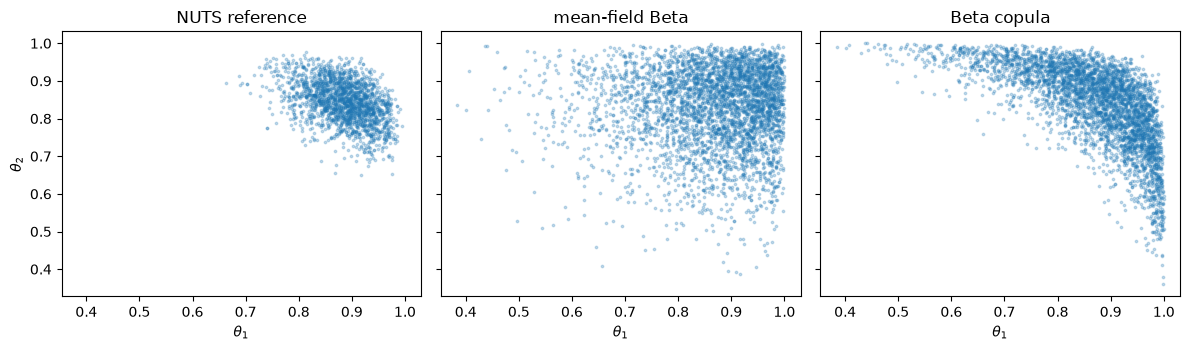

In [5]:

fig, axes = plt.subplots(1, 3, figsize=(12, 3.6), sharex=True, sharey=True)
for ax, (samp, title) in zip(axes, [
        ((np.asarray(ref["t1"]), np.asarray(ref["t2"])), "NUTS reference"),
        ((np.asarray(th_mf[:, 0]), np.asarray(th_mf[:, 1])), "mean-field Beta"),
        ((np.asarray(th_cop[:, 0]), np.asarray(th_cop[:, 1])), "Beta copula")]):
    ax.scatter(samp[0], samp[1], s=3, alpha=0.25)
    ax.set_title(title)
    ax.set_xlabel(r"$\theta_1$")
axes[0].set_ylabel(r"$\theta_2$")
plt.tight_layout()

The mean-field guide has to widen both marginals to cover the ridge and
still misses the geometry; independent draws multiply into an inflated
uncertainty for the system reliability, the one number the data pin
down well (sd 0.125 against 0.051 under NUTS). The copula recovers the
shape and most of the product precision (sd 0.083). Its latent
correlation comes out stronger than the NUTS value because the Beta
shapes are capped at the table domain [0.1, 10]: the marginals are
slightly wide and the ELBO optimum leans on the copula to compensate,
in the direction that tightens the product.

Nothing here is specific to two dimensions or to Beta marginals: a
Cholesky factor replaces rho in higher dimensions, and any chebax
quantile can serve as a marginal (`gammaincinv` for scales,
`stdtrit` for heavy tails, `vonmises_icdf` for angles). The pattern is
a small, transparent alternative to a normalizing flow whenever the
posterior is "correlated with known marginal families".

# A t-copula with learned degrees of freedom

The Gaussian copula has one structural blind spot: no tail dependence.
Joint extremes decouple, whatever rho says. The classical fix is the
Student-t copula, and it is one mixing variable away from the Gaussian
one:

    w = chi2_nu / nu,   t_i = z_i / sqrt(w),   u_i = stdtr(nu, t_i)

Sampling w reparameterized in nu needs the chi-square quantile,
`chi2inv(nu, u)`; the CDF `stdtr` is traced in nu. Both carry
implicit-function-theorem gradients, so nu is just one more guide
parameter for Adam. The family nests the Gaussian copula (nu large), so
the ELBO can simply decide whether heavy joint tails are worth having.

The guide density follows the same change-of-variables pattern with the
bivariate t replacing the bivariate normal:

$$\log q(\theta) = \log f_{t_2}(t;\rho,\nu) + \sum_i \big[\log
f_{\mathrm{Beta}}(\theta_i; a_i, b_i) - \log f_{t_1}(t_i;\nu)\big]$$

In [6]:
from jax.scipy.special import gammaln


def unpack_t(phi):
    ab = 0.2 + 9.6 * jax.nn.sigmoid(phi[:4])
    rho = jnp.tanh(phi[4])
    nu = 0.3 + 19.0 * jax.nn.sigmoid(phi[5])  # stdtr covers nu in [0.2, 20]
    return ab[0], ab[1], ab[2], ab[3], rho, nu


def t1_logpdf(t, nu):
    return (gammaln((nu + 1) / 2) - gammaln(nu / 2)
            - 0.5 * jnp.log(nu * jnp.pi) - (nu + 1) / 2 * jnp.log1p(t * t / nu))


def t2_logpdf(t1, t2, rho, nu):
    q = (t1 * t1 - 2 * rho * t1 * t2 + t2 * t2) / (1 - rho ** 2)
    return (gammaln((nu + 2) / 2) - gammaln(nu / 2) - jnp.log(nu * jnp.pi)
            - 0.5 * jnp.log1p(-rho ** 2) - (nu + 2) / 2 * jnp.log1p(q / nu))


def t_guide_sample(phi, eps, ug):
    """eps: (M, 2) standard normal, ug: (M,) uniform for the chi2 mixing."""
    a1, b1, a2, b2, rho, nu = unpack_t(phi)
    z1 = eps[:, 0]
    z2 = rho * eps[:, 0] + jnp.sqrt(1.0 - rho ** 2) * eps[:, 1]
    chi2 = chebax.chi2inv(nu, jnp.clip(ug, 1e-12, 1 - 1e-12))
    w = jnp.sqrt(chi2 / nu)
    t1, t2 = z1 / w, z2 / w
    u1 = jnp.clip(chebax.stdtr(nu, t1), 1e-14, 1 - 1e-14)
    u2 = jnp.clip(chebax.stdtr(nu, t2), 1e-14, 1 - 1e-14)
    th1 = chebax.betaincinv(a1, b1, u1)
    th2 = chebax.betaincinv(a2, b2, u2)
    log_q = (t2_logpdf(t1, t2, rho, nu)
             + beta_stats.logpdf(th1, a1, b1) - t1_logpdf(t1, nu)
             + beta_stats.logpdf(th2, a2, b2) - t1_logpdf(t2, nu))
    return jnp.stack([th1, th2], axis=1), log_q


def neg_elbo_t(phi, eps, ug):
    theta, log_q = t_guide_sample(phi, eps, ug)
    return -(jax.vmap(log_joint)(theta[:, 0], theta[:, 1]) - log_q).mean()


def train_t(steps=1500, m=256, lr=0.02, seed=10):
    grad_fn = jax.jit(jax.value_and_grad(neg_elbo_t))
    phi = jnp.zeros(6)
    mom = vel = jnp.zeros_like(phi)
    b1, b2, e = 0.9, 0.999, 1e-8
    key = jax.random.PRNGKey(seed)
    for i in range(steps):
        key, k1, k2 = jax.random.split(key, 3)
        eps = jax.random.normal(k1, (m, 2))
        ug = jax.random.uniform(k2, (m,))
        val, g = grad_fn(phi, eps, ug)
        mom = b1 * mom + (1 - b1) * g
        vel = b2 * vel + (1 - b2) * g * g
        phi = phi - lr * (mom / (1 - b1 ** (i + 1))) / (
            jnp.sqrt(vel / (1 - b2 ** (i + 1))) + e)
    eps = jax.random.normal(jax.random.PRNGKey(99), (40000, 2))
    ug = jax.random.uniform(jax.random.PRNGKey(98), (40000,))
    return phi, -float(neg_elbo_t(phi, eps, ug))


phi_t, elbo_t = train_t()
nu_learned = float(unpack_t(phi_t)[5])
rho_learned = float(unpack_t(phi_t)[4])
print(f"ELBO  gaussian copula: {elbo_cop:.4f}")
print(f"ELBO  t copula:        {elbo_t:.4f}")
print(f"learned nu = {nu_learned:.2f}, rho = {rho_learned:+.3f}")

E0801 18:32:07.564390 1859608 algebraic_simplifier.cc:10574] Algebraic simplifier is likely stuck in a circular simplification loop and ran for 50 runs on computation region_31.53


ELBO  gaussian copula: -10.7932
ELBO  t copula:        -10.8045
learned nu = 17.93, rho = -0.736


## What tail dependence looks like

The outcome above is the nesting property doing its job: this posterior
is a smooth ridge with no joint extremes, so the ELBO pushes nu to the
Gaussian end of its box (~18) and matches the Gaussian copula to within
a hundredth of a nat. The guide did not need heavy tails, and with nu
learnable it was allowed to say so. To see what the extra parameter can
express when the data do call for it, compare the copulas themselves
(uniform marginals, same rho) at a small fixed nu: the t-copula
concentrates probability in the joint corners, where the Gaussian one
goes empty.

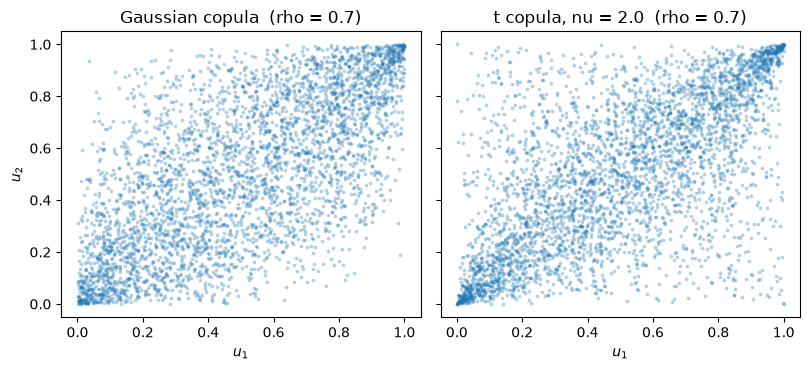

In [7]:
key = jax.random.PRNGKey(3)
k1, k2 = jax.random.split(key)
eps = jax.random.normal(k1, (4000, 2))
ug = jax.random.uniform(k2, (4000,))
rho_show, nu_show = 0.7, 2.0

z1 = eps[:, 0]
z2 = rho_show * eps[:, 0] + jnp.sqrt(1 - rho_show ** 2) * eps[:, 1]
u_gauss = norm_stats.cdf(jnp.stack([z1, z2], axis=1))

w = jnp.sqrt(chebax.chi2inv(nu_show, ug) / nu_show)
u_t = chebax.stdtr(nu_show, jnp.stack([z1 / w, z2 / w], axis=1))

fig, axes = plt.subplots(1, 2, figsize=(8.2, 3.8), sharex=True, sharey=True)
for ax, u, title in [(axes[0], np.asarray(u_gauss), "Gaussian copula"),
                     (axes[1], np.asarray(u_t), f"t copula, nu = {nu_show}")]:
    ax.scatter(u[:, 0], u[:, 1], s=3, alpha=0.25)
    ax.set_title(f"{title}  (rho = {rho_show})")
    ax.set_xlabel("$u_1$")
axes[0].set_ylabel("$u_2$")
plt.tight_layout()

Both panels share the marginals and the correlation; only the joint
tails differ. When the posterior (or the data, in a copula-likelihood
model) actually has joint extremes, that corner mass is what the
Gaussian family cannot buy at any rho, and nu is one Adam parameter
away here. The whole chain stays reparameterized: chi-square quantile
in nu (`gammaincinv`), CDF in nu and t (`stdtr`), marginal quantile in
its shapes (`betaincinv`), all with implicit-function-theorem
gradients.